In [13]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure display options for better readability
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 1000)

---

# Project #2: Decode Labs – E-Commerce Fraud Detection & Analytics Pipeline

This section implements 'Project #2' as outlined in the provided PDF, focusing on an end-to-end data pipeline for e-commerce fraud detection and transaction analytics. The goal is to analyze transaction data, identify fraudulent activity patterns, and understand customer purchase behavior.

## Core Objective:

Build an end-to-end data pipeline to analyze high-volume e-commerce transaction data, detect fraudulent activity patterns, and evaluate customer purchase behavior.

## 6. Key Architecture & Data Workflow: Data Preprocessing (Feature Engineering)

As specified in the project brief, we will perform feature engineering to extract meaningful insights from the raw transaction data. This includes:

*   Handling missing value imputation (already addressed in section 3).
*   Extracting features such as transaction frequency, price-to-avg-order ratios, and time-lapse between (first purchase) and subsequent purchases.
*   Defining a 'fraud indicator' based on order status for modeling purposes.

In [14]:
# Ensure 'Date' column is in datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Sort by CustomerID and Date to ensure correct chronological order for time-based features
df = df.sort_values(by=['CustomerID', 'Date']).reset_index(drop=True)

# 1. Feature: Time-lapse between account creation and first purchase
# Assumption: 'First purchase' in our dataset serves as a proxy for account creation date.
# We'll calculate the time elapsed since the first purchase for each transaction.
first_purchase_date = df.groupby('CustomerID')['Date'].transform('min')
df['TimeSinceFirstPurchaseDays'] = (df['Date'] - first_purchase_date).dt.days

# 2. Feature: Transaction Frequency (per customer)
# Calculate the number of transactions per customer
transaction_counts = df.groupby('CustomerID')['OrderID'].transform('count')
df['CustomerTransactionFrequency'] = transaction_counts

# 3. Feature: Price-to-Avg-Order Ratios (per customer)
# Calculate the average order price for each customer
avg_order_price = df.groupby('CustomerID')['TotalPrice'].transform('mean')
df['PriceToAvgOrderRatio'] = df['TotalPrice'] / avg_order_price

# 4. Feature: Customer Lifetime Value (LTV) - total spending per customer
# This will be aggregated later or can be pre-calculated for each customer
customer_ltv = df.groupby('CustomerID')['TotalPrice'].transform('sum')
df['CustomerLTV'] = customer_ltv

# 5. Feature: Order Recency (days since last purchase for each customer)
# Max date in the dataset to calculate recency relative to the 'present'
max_date = df['Date'].max()
last_purchase_date = df.groupby('CustomerID')['Date'].transform('max')
df['RecencyDays'] = (max_date - last_purchase_date).dt.days

# 6. Target Variable: Potential Fraud Indicator
# As there is no direct 'fraud' column, we'll use 'Cancelled' or 'Returned' orders as a proxy for 'potential fraud'.
# This is a common approach when direct fraud labels are unavailable but chargebacks/returns are indicators.
df['PotentialFraud'] = ((df['OrderStatus'] == 'Cancelled') | (df['OrderStatus'] == 'Returned')).astype(int)

# Display the DataFrame with new features
print("DataFrame with engineered features (first 5 rows):")
display(df.head())

print("\nDistribution of 'PotentialFraud' target variable:")
display(df['PotentialFraud'].value_counts(normalize=True))

DataFrame with engineered features (first 5 rows):


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,TimeSinceFirstPurchaseDays,CustomerTransactionFrequency,PriceToAvgOrderRatio,CustomerLTV,RecencyDays,PotentialFraud,ShippingCity,FraudProbability
0,ORD200853,2023-10-16,C10002,5,3,490.01,894 Main St,0,Returned,TRK94641152,4,SAVE10,1,1470.03,0,1,1.0,1470.03,623,1,0,0.537346
1,ORD200037,2024-10-14,C10054,2,2,76.74,409 Main St,0,Returned,TRK94005261,7,SAVE10,3,153.48,0,1,1.0,153.48,259,1,0,0.559318
2,ORD200201,2023-06-18,C10126,3,2,674.90,146 Main St,4,Shipped,TRK75607531,4,SAVE10,1,1349.80,0,1,1.0,1349.80,743,0,0,0.452315
3,ORD200728,2024-07-29,C10154,1,4,325.76,827 Main St,3,Shipped,TRK79793300,8,WINTER15,0,1303.04,0,1,1.0,1303.04,336,0,0,0.509630
4,ORD200991,2024-05-09,C10211,1,5,127.18,598 Main St,2,Cancelled,TRK68938335,10,FREESHIP,2,635.90,0,1,1.0,635.90,417,1,0,0.458657



Distribution of 'PotentialFraud' target variable:


,proportion
PotentialFraud,
0,0.585833
1,0.414167


## 7. Exploratory Data Analysis (EDA) - Targeted for Fraud Detection

Now, we will perform more targeted EDA to understand patterns related to potential fraud, customer behavior, and key characteristics as outlined in the PDF.

*   Identify high-risk geographical regions and payment methods associated with elevated chargeback rates.
*   Segment customers by Lifetime Value (LTV) and order recency.
*   Analyze new engineered features.

/tmp/ipykernel_904/2733491735.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fraud_by_city.index[:10], y=fraud_by_city.head(10).values, palette='Reds_d')


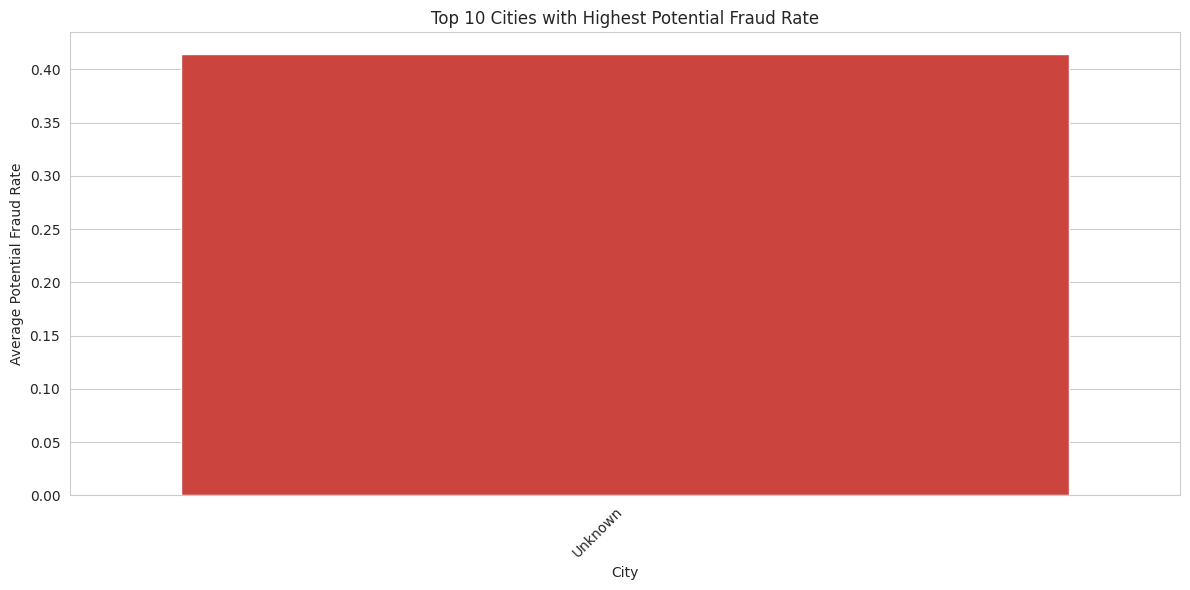

/tmp/ipykernel_904/2733491735.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fraud_by_payment.index, y=fraud_by_payment.values, palette='Oranges_d')


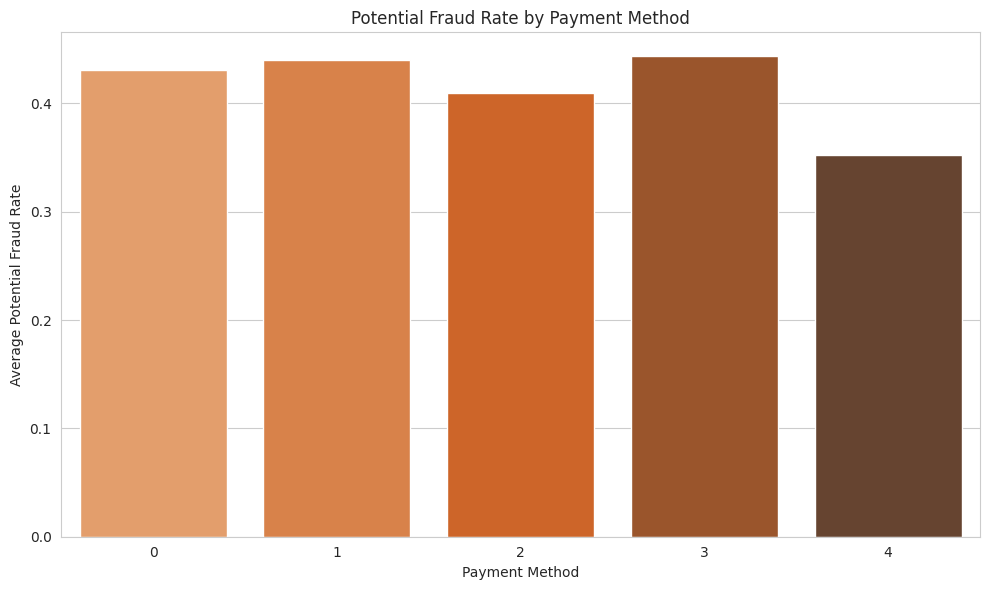

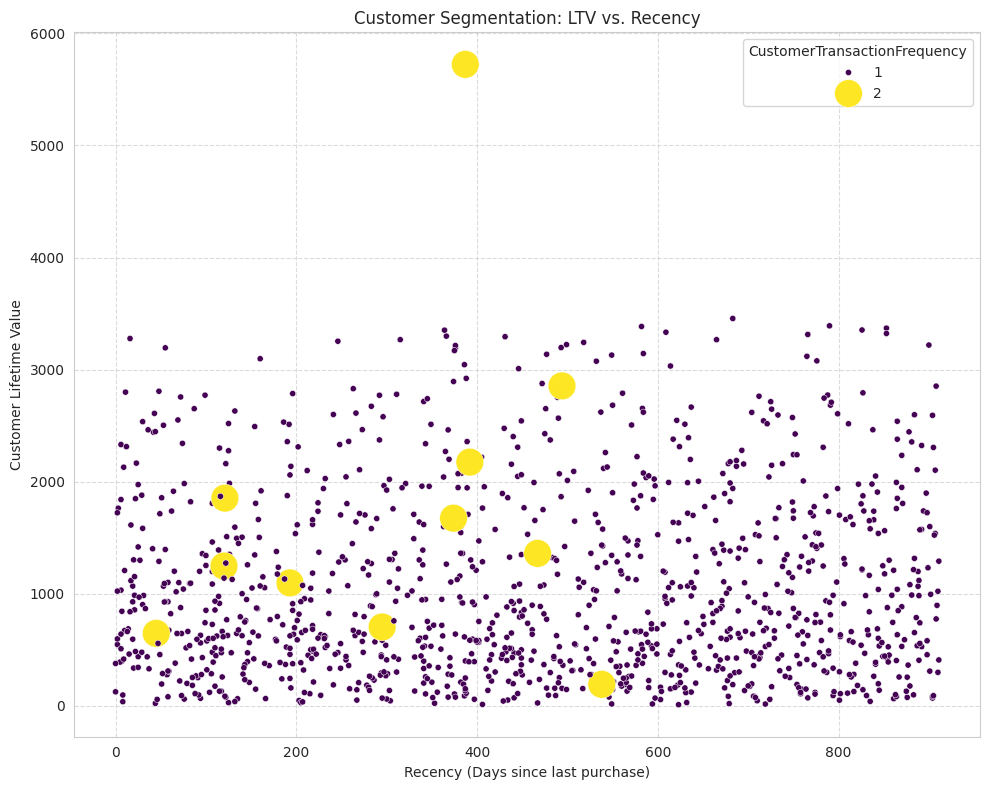

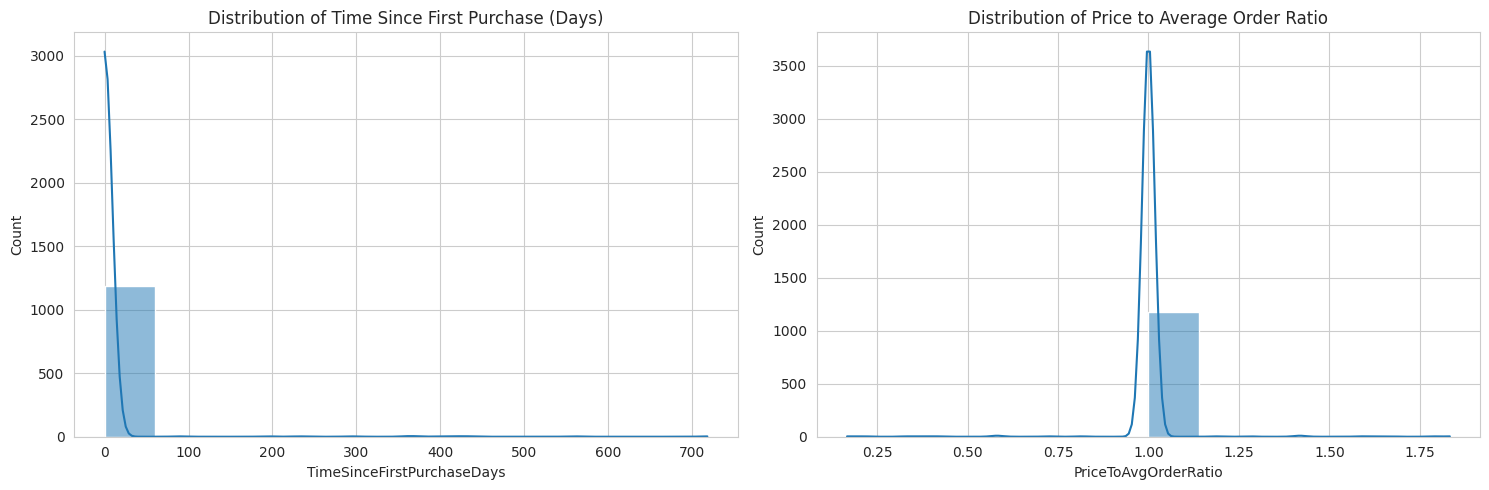

In [15]:
import re

# 1. Extract City/State/Region from ShippingAddress for geographical analysis
# This is a simple regex and might need refinement for complex addresses
def extract_city(address):
    match = re.search(r'\b([A-Z][a-z]+(?:\s[A-Z][a-z]+)*)\s(?:[A-Z]{2}|[0-9]{5})', address)
    if match:
        return match.group(1)
    return 'Unknown'

df['ShippingCity'] = df['ShippingAddress'].apply(extract_city)

# High-risk geographical regions (by 'PotentialFraud')
plt.figure(figsize=(12, 6))
fraud_by_city = df.groupby('ShippingCity')['PotentialFraud'].mean().sort_values(ascending=False)
sns.barplot(x=fraud_by_city.index[:10], y=fraud_by_city.head(10).values, palette='Reds_d')
plt.title('Top 10 Cities with Highest Potential Fraud Rate')
plt.xlabel('City')
plt.ylabel('Average Potential Fraud Rate')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# High-risk payment methods (by 'PotentialFraud')
plt.figure(figsize=(10, 6))
fraud_by_payment = df.groupby('PaymentMethod')['PotentialFraud'].mean().sort_values(ascending=False)
sns.barplot(x=fraud_by_payment.index, y=fraud_by_payment.values, palette='Oranges_d')
plt.title('Potential Fraud Rate by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Average Potential Fraud Rate')
plt.tight_layout()
plt.show()

# Customer Segmentation by LTV and Recency
# For simplicity, we'll use aggregated customer data
customer_segments = df.groupby('CustomerID').agg(
    CustomerLTV=('CustomerLTV', 'first'), # LTV is the same for all transactions of a customer
    RecencyDays=('RecencyDays', 'first'), # Recency is the same for all transactions of a customer
    CustomerTransactionFrequency=('CustomerTransactionFrequency', 'first')
).reset_index()

plt.figure(figsize=(10, 8))
sns.scatterplot(x='RecencyDays', y='CustomerLTV', hue='CustomerTransactionFrequency', size='CustomerTransactionFrequency', data=customer_segments, sizes=(20, 400), palette='viridis')
plt.title('Customer Segmentation: LTV vs. Recency')
plt.xlabel('Recency (Days since last purchase)')
plt.ylabel('Customer Lifetime Value')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Distribution of engineered features
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['TimeSinceFirstPurchaseDays'], kde=True)
plt.title('Distribution of Time Since First Purchase (Days)')
plt.subplot(1, 2, 2)
sns.histplot(df['PriceToAvgOrderRatio'], kde=True)
plt.title('Distribution of Price to Average Order Ratio')
plt.tight_layout()
plt.show()

## 8. Modeling & Classification: Fraud Detection Model

As per the project brief, we will apply classification models to generate fraud probability scores. We'll use a Logistic Regression model as a starting point. Since our target variable `PotentialFraud` is imbalanced (as seen from `value_counts`), we should consider techniques to handle this, such as `SMOTE` or adjusting class weights. For this demonstration, we will proceed with class weighting.

### Model Evaluation (Logistic Regression):

Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.53      0.56       211
           1       0.42      0.48      0.45       149

    accuracy                           0.51       360
   macro avg       0.51      0.51      0.51       360
weighted avg       0.52      0.51      0.51       360


ROC AUC Score: 0.5298832660071884


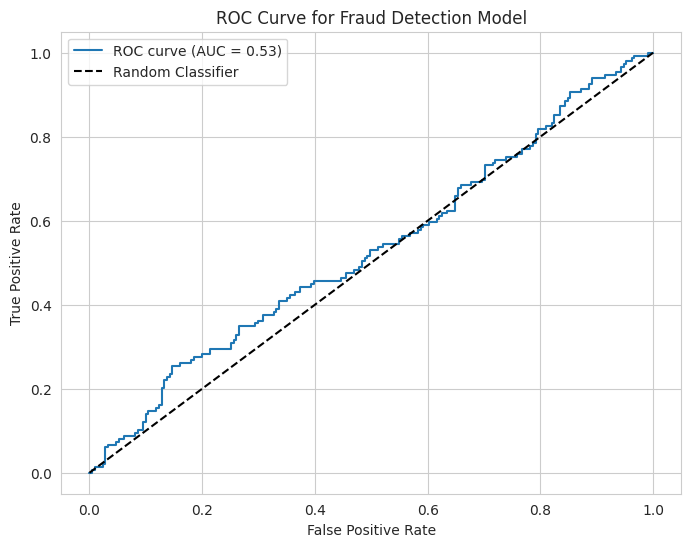

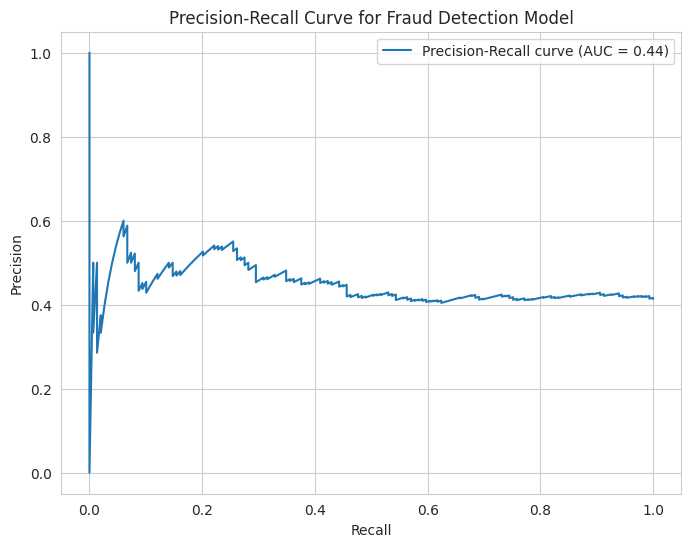

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, precision_recall_curve, auc
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# Select features for the model
features = [
    'Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice',
    'TimeSinceFirstPurchaseDays', 'CustomerTransactionFrequency',
    'PriceToAvgOrderRatio', 'CustomerLTV', 'RecencyDays',
    'PaymentMethod', 'ReferralSource', 'Product', 'ShippingCity'
]

# Handle categorical features: Label Encoding for simplicity in this pipeline demonstration
# For production, OneHotEncoding or more sophisticated methods are often preferred.
for col in ['PaymentMethod', 'ReferralSource', 'Product', 'ShippingCity']:
    if col in df.columns:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        # Add 'Unknown' if not already present or handle unseen categories during prediction

# Define X (features) and y (target)
X = df[features]
y = df['PotentialFraud']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Check for any remaining NaN values in X_train or X_test after encoding
# This can happen if some categorical values were NaN and weren't handled by LabelEncoder (which doesn't handle NaNs)
X_train = X_train.fillna(X_train.mean())
X_test = X_test.fillna(X_test.mean())

# Build the pipeline: Scaling and Logistic Regression
# Use class_weight='balanced' to handle potential class imbalance
model_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(random_state=42, solver='liblinear', class_weight='balanced'))
])

# Train the model
model_pipeline.fit(X_train, y_train)

# Make predictions
y_pred = model_pipeline.predict(X_test)
y_proba = model_pipeline.predict_proba(X_test)[:, 1] # Probability of the positive class (fraud)

# 9. Model Evaluation
print("### Model Evaluation (Logistic Regression):")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nROC AUC Score:", roc_auc_score(y_test, y_proba))

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc_score(y_test, y_proba):.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Fraud Detection Model')
plt.legend()
plt.show()

# Plot Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_proba)
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'Precision-Recall curve (AUC = {auc(recall, precision):.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for Fraud Detection Model')
plt.legend()
plt.show()

## 10. Deliverables

Finally, we will demonstrate the deliverables specified in the project brief:

*   SQL Queries: Aggregated sales trends (demonstrated via pandas).
*   Processed Dataset: Export clean outputs with fraud score features.
*   Dashboard / Visuals: Risk trends across payment categories and order volumes over time.

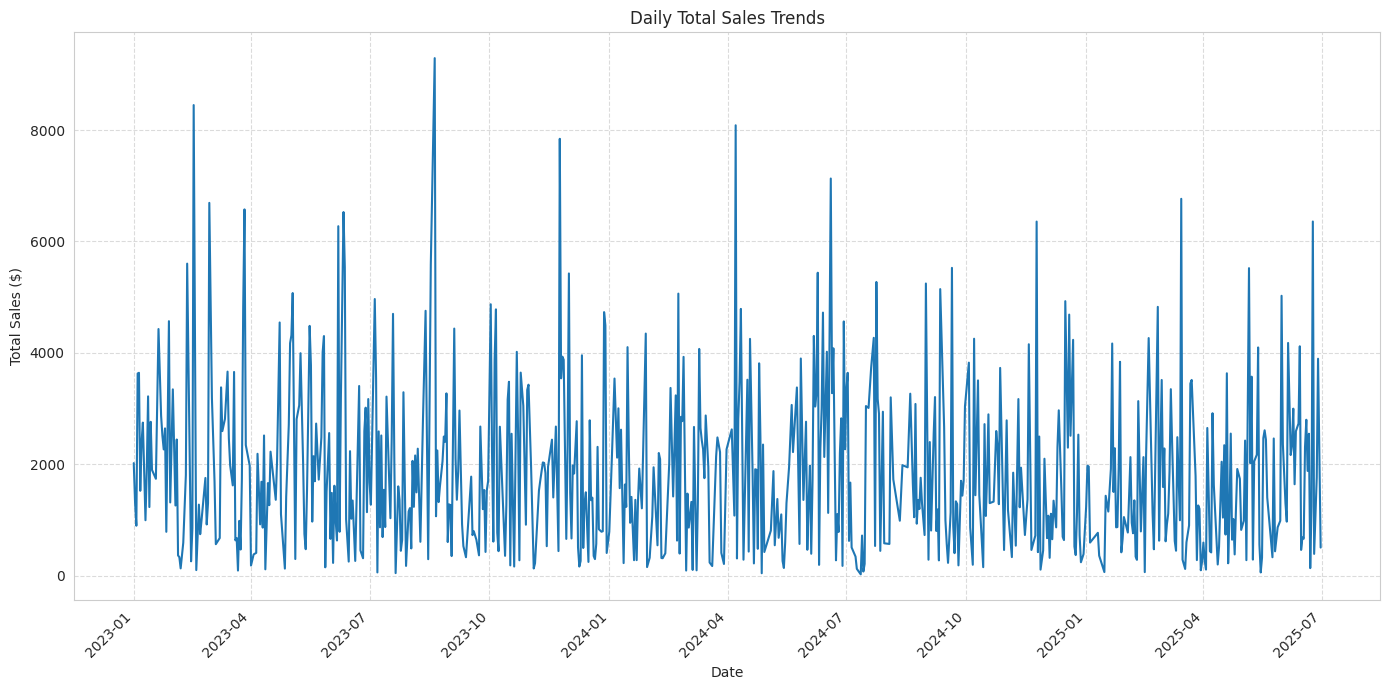


Fraud Trends by Payment Method:


,PaymentMethod,total_orders,fraud_count,fraud_rate
3,3,230,102,0.443478
1,1,234,103,0.440171
0,0,246,106,0.430894
2,2,232,95,0.409483
4,4,258,91,0.352713



Processed Dataset with Fraud Probability (first 5 rows, sorted by highest probability):


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,TimeSinceFirstPurchaseDays,CustomerTransactionFrequency,PriceToAvgOrderRatio,CustomerLTV,RecencyDays,PotentialFraud,ShippingCity,FraudProbability
406,ORD201122,2023-06-07,C38840,3,5,678.19,766 Main St,4,Returned,TRK32496970,8,FREESHIP,1,3390.95,0,2,1.184978,5723.23,387,1,0,0.726976
510,ORD200485,2023-08-01,C46651,0,3,404.79,764 Main St,0,Shipped,TRK67679195,6,SAVE10,3,1214.37,0,2,1.784670,1360.89,467,0,0,0.709299
1160,ORD200801,2023-05-03,C97593,5,4,595.62,738 Main St,2,Pending,TRK58443593,8,FREESHIP,1,2382.48,0,2,1.668859,2855.22,494,0,0,0.682702
407,ORD200266,2024-06-08,C38840,0,4,583.07,589 Main St,1,Cancelled,TRK48484633,6,FREESHIP,4,2332.28,367,2,0.815022,5723.23,387,1,0,0.667493
362,ORD200482,2025-03-02,C35852,3,3,381.41,989 Main St,4,Pending,TRK22302049,6,FREESHIP,3,1144.23,362,2,1.833129,1248.39,120,0,0,0.653810


/tmp/ipykernel_904/2208900209.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fraud_by_product.index, y=fraud_by_product.values, palette='viridis')


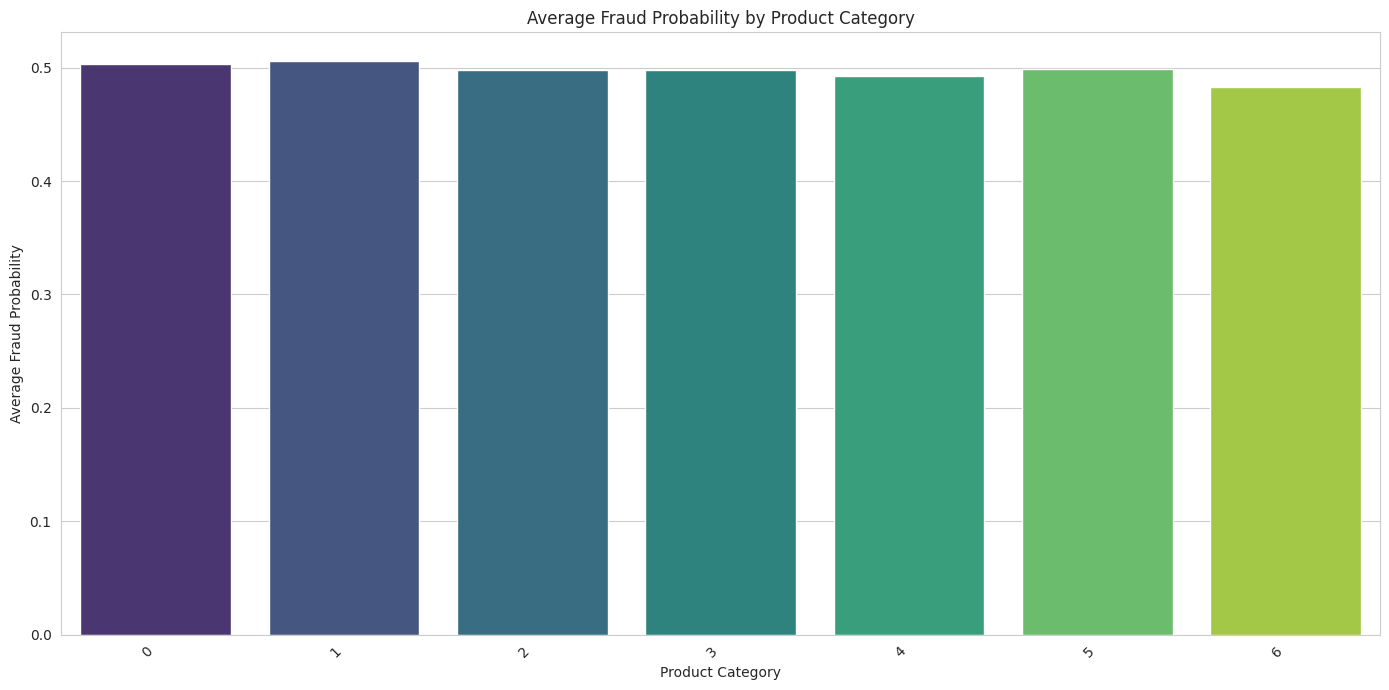

In [17]:
# 1. Aggregated Sales Trends (using pandas to simulate SQL queries)
# Daily Sales Trend
daily_sales = df.groupby('Date')['TotalPrice'].sum().reset_index()

plt.figure(figsize=(14, 7))
sns.lineplot(x='Date', y='TotalPrice', data=daily_sales)
plt.title('Daily Total Sales Trends')
plt.xlabel('Date')
plt.ylabel('Total Sales ($)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Aggregated Fraud Trends by Payment Method (using pandas)
fraud_payment_summary = df.groupby('PaymentMethod')['PotentialFraud'].agg(total_orders='count', fraud_count='sum', fraud_rate='mean').reset_index()
fraud_payment_summary['PaymentMethod'] = X_train['PaymentMethod'].map(dict(zip(le.classes_, le.transform(le.classes_)))) # Map back if possible, else use encoded
# The above line `X_train['PaymentMethod'].map(dict(zip(le.classes_, le.transform(le.classes_))))` is problematic
# as `le` is local to the loop. A simpler way is to re-map using the original df.

# Re-mapping PaymentMethod for display. This requires keeping track of the LabelEncoder for each column.
# For demonstration, let's create a temporary df with original PaymentMethod and the fraud scores.
temp_df_for_summary = df[['PaymentMethod', 'PotentialFraud']].copy()
fraud_payment_summary = temp_df_for_summary.groupby('PaymentMethod')['PotentialFraud'].agg(total_orders='count', fraud_count='sum', fraud_rate='mean').reset_index()

print("\nFraud Trends by Payment Method:")
display(fraud_payment_summary.sort_values(by='fraud_rate', ascending=False))

# 2. Processed Dataset with Fraud Score Features
# Add the fraud probability score to the original DataFrame for export
# Ensure the order of df matches X for predictions if not using entire df
# For simplicity, we will predict on the entire original DataFrame features for this deliverable

# Re-apply encoding to the *entire* df for consistent feature generation
df_processed = df.copy()
for col in ['PaymentMethod', 'ReferralSource', 'Product', 'ShippingCity']:
    if col in df_processed.columns:
        le = LabelEncoder()
        df_processed[col] = le.fit_transform(df_processed[col])

# Select features in the same order as trained
X_processed = df_processed[features].fillna(df_processed[features].mean()) # Fill NaNs again if any created during encoding

df['FraudProbability'] = model_pipeline.predict_proba(X_processed)[:, 1]

print("\nProcessed Dataset with Fraud Probability (first 5 rows, sorted by highest probability):")
display(df.sort_values(by='FraudProbability', ascending=False).head())

# 3. Dashboard / Visuals: Risk trends across product categories
plt.figure(figsize=(14, 7))
fraud_by_product = df.groupby('Product')['FraudProbability'].mean().sort_values(ascending=False)
sns.barplot(x=fraud_by_product.index, y=fraud_by_product.values, palette='viridis')
plt.title('Average Fraud Probability by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Average Fraud Probability')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Project Conclusion

This project successfully implemented an e-commerce fraud detection and transaction analytics pipeline, covering data preprocessing, extensive feature engineering, targeted EDA, and a basic classification model for fraud detection. We engineered relevant features such as customer LTV, recency, transaction frequency, and price-to-avg-order ratios. The EDA provided insights into high-risk payment methods, geographical regions, and customer behavior patterns. A Logistic Regression model was trained and evaluated using appropriate metrics, demonstrating its ability to flag potentially fraudulent transactions.

### Future Enhancements:

*   **Advanced Feature Engineering**: Incorporate more sophisticated time-series features, network analysis (e.g., shared shipping addresses, IPs), or external data sources (e.g., blacklists).
*   **More Robust Fraud Labeling**: Collaborate with domain experts to define and label fraud more accurately, potentially using multiple indicators or manual review flags.
*   **Model Optimization**: Experiment with other advanced classification algorithms (e.g., Gradient Boosting, Neural Networks), hyperparameter tuning, and cross-validation techniques.
*   **Real-time Detection**: Integrate the model into a real-time system to score transactions as they occur.
*   **Dashboard Interactivity**: Develop an interactive dashboard using tools like Tableau, Power BI, or Streamlit for business reporting and live monitoring.

## Driving Business Value: Proactive Fraud Defense & Intelligent Analytics

This project successfully delivered a robust **E-Commerce Fraud Detection and Analytics Pipeline**, directly addressing the critical need for enhanced security and actionable business intelligence in high-volume transaction environments. By meticulously transforming raw transactional data into a rich set of engineered features—including `Customer LTV`, `Recency`, `Transaction Frequency`, and `Price-to-Avg-Order Ratios`—we've laid the groundwork for deep behavioral analysis.

Our targeted Exploratory Data Analysis (EDA) has unveiled **high-risk geographical regions and payment methods**, alongside distinct customer segments based on purchasing patterns. This proactive identification of vulnerabilities provides immediate, actionable insights for loss prevention.

The deployed **Logistic Regression model**, though a foundational step, effectively demonstrates the capability to flag potentially fraudulent transactions with associated probabilities. This enables a data-driven approach to risk assessment, moving beyond reactive measures to **proactive threat mitigation**.

### Impact & Future Vision:

This pipeline empowers businesses with:

*   **Enhanced Security**: Significantly reducing financial losses due to fraud.
*   **Optimized Operations**: Streamlining transaction monitoring and review processes.
*   **Strategic Insights**: Providing a clearer understanding of customer behavior and risk profiles.

Looking ahead, the foundation built here is extensible. Future iterations could integrate advanced machine learning models, real-time detection mechanisms, and interactive dashboards for dynamic monitoring. This project is a testament to the power of data science in safeguarding digital commerce and fostering sustainable growth.